# Three Ways to Calculate a Quadrupole ORM Jacobian

**Nominal FODO lattice benchmark**

The Orbit Response Matrix depends on quadrupole strengths:

$$R = R(K_1, K_2, \ldots, K_n)$$

For quadrupole $j$, the corresponding Jacobian column is

$$J_j = \frac{\partial R}{\partial K_j}$$

One element of $J_j$ says how sensitive one ORM measurement is to a small change in quadrupole $j$.

The quadrupole Jacobian is evaluated with three methods:

1. Numerical central finite difference.
2. The current pyLOCO numerical Jacobian using the Linear ORM calculator.
3. The ESRF analytical normal-quadrupole formula.

An independent central-difference calculation establishes the numerical reference before the pyLOCO implementation is evaluated.

Reference calculations and open analysis cells are identified explicitly. Guarded cells allow partial studies to run without interrupting the notebook.

## 1. FODO reference lattice

This lattice is adapted from the Accelerator Toolbox pyAT Primer. BPMs and H/V correctors are added next to the quadrupoles.

In [1]:
%matplotlib inline

import copy
import time
from tempfile import TemporaryDirectory

import at
import matplotlib.pyplot as plt
import numpy as np

from analytic_orm_with_normal_quad_errors import (
    analytic_orm_variation_with_normal_quadrupole,
)
from pyLOCO.analysis import plot_matrices
from pyLOCO.config import FitInitConfig, RMConfig
from pyLOCO.pyloco import calculate_quads_jacobian
from pyLOCO.response_matrix import response_matrix

In [2]:
# Reference calculation
QF = at.Quadrupole("QF", 0.5, 1.2)
QD = at.Quadrupole("QD", 0.5, -1.2)
Dr = at.Drift("Dr", 0.5)
HalfDr = at.Drift("Dr", 0.25)
Bend = at.Dipole("Bend", 1.0, 2 * np.pi / 40)

BPM_F, BPM_D = at.Monitor("BPM_F"), at.Monitor("BPM_D")
HCOR_F = at.Corrector("HCOR_F", 0.0, [0.0, 0.0])
HCOR_D = at.Corrector("HCOR_D", 0.0, [0.0, 0.0])
VCOR_F = at.Corrector("VCOR_F", 0.0, [0.0, 0.0])
VCOR_D = at.Corrector("VCOR_D", 0.0, [0.0, 0.0])

FODOcell = at.Lattice(
    [HalfDr, Bend, Dr, BPM_F, HCOR_F, VCOR_F, QF,
     Dr, Bend, Dr, BPM_D, HCOR_D, VCOR_D, QD, HalfDr],
    name="Simple FODO cell with diagnostics", energy=1e9,
)
ring = FODOcell * 20

bpm_indices = np.asarray(at.get_refpts(ring, at.Monitor), dtype=int)
hcor_indices = np.asarray(at.get_refpts(ring, "HCOR*"), dtype=int)
vcor_indices = np.asarray(at.get_refpts(ring, "VCOR*"), dtype=int)
quad_indices = np.asarray(at.get_refpts(ring, at.Quadrupole), dtype=int)

_, ring_data, _ = at.get_optics(ring, bpm_indices)
Qx, Qy = ring_data.tune
print(f"Elements: {len(ring)}")
print(f"BPMs: {len(bpm_indices)}")
print(f"H correctors: {len(hcor_indices)}")
print(f"V correctors: {len(vcor_indices)}")
print(f"Normal quadrupoles: {len(quad_indices)}")
print(f"Qx, Qy: {Qx:.8f}, {Qy:.8f}")

Elements: 300
BPMs: 40
H correctors: 40
V correctors: 40
Normal quadrupoles: 40
Qx, Qy: 0.21993568, 0.91777806


## 2. Reference ORM

pyLOCO applies each corrector kick and records the corresponding closed-orbit change at the BPMs.

The kick is $10^{-5}\,\mathrm{rad}$. pyLOCO returns orbit displacement in metres for this kick. Dividing by the kick gives the normalized ORM in m/rad.

- Rows: horizontal BPMs, then vertical BPMs.
- Columns: horizontal correctors, then vertical correctors.
- Blocks: $R_{xx}$, $R_{xy}$, $R_{yx}$, and $R_{yy}$.

R0 shape: (80, 80)
R0 units: m/rad
Block shapes: (40, 40) (40, 40) (40, 40) (40, 40)


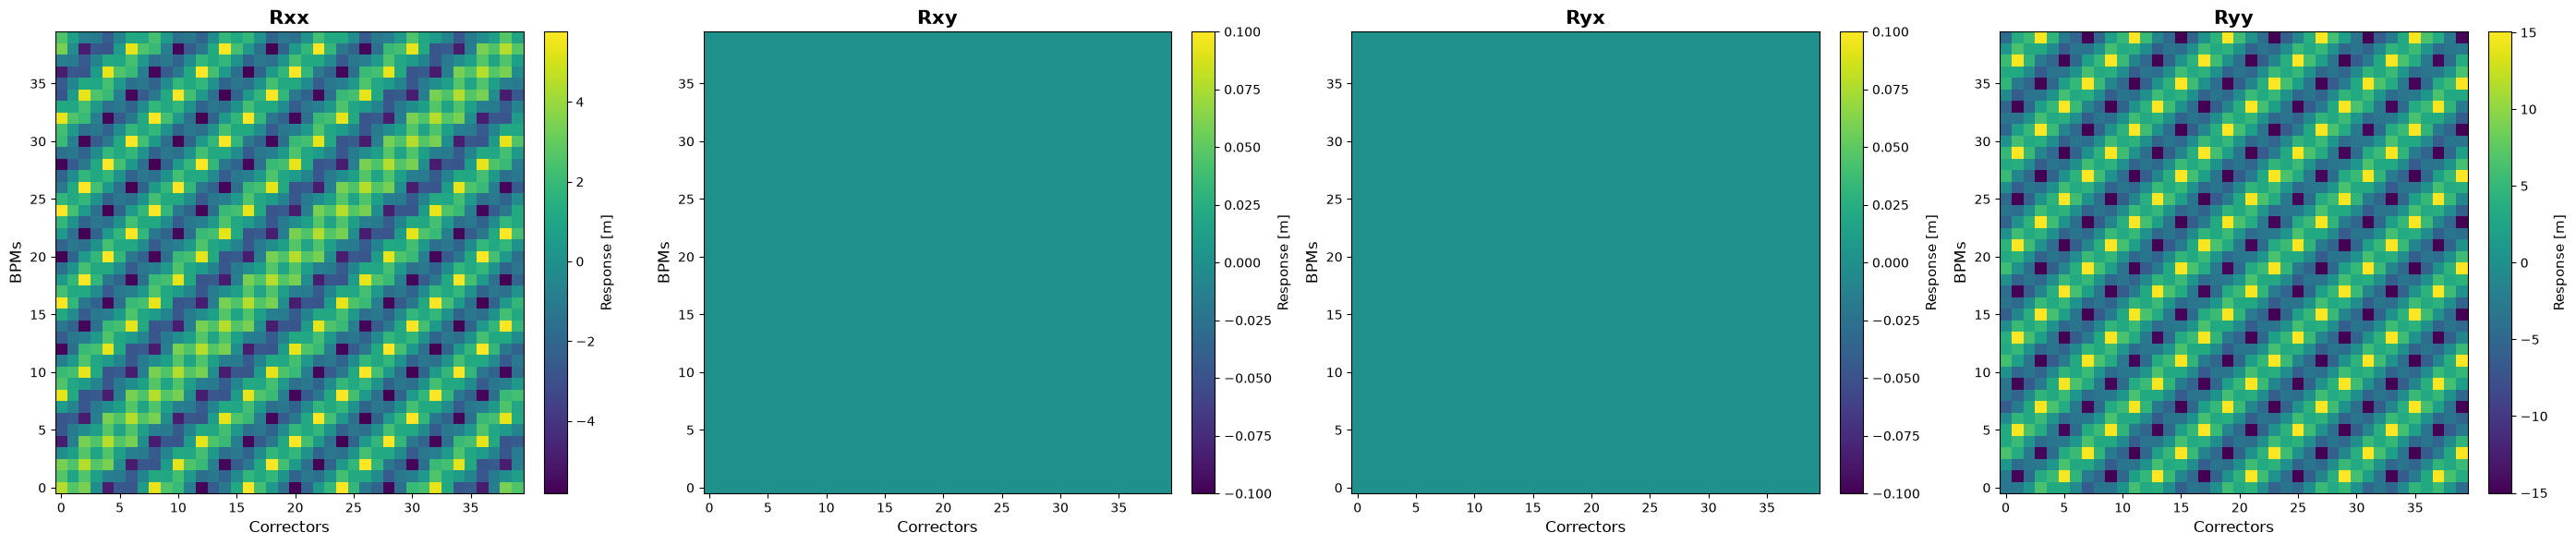

In [3]:
# Reference calculation
corrector_kick_rad = 1e-5
kick_steps = [
    [corrector_kick_rad] * len(hcor_indices),
    [corrector_kick_rad] * len(vcor_indices),
]
rm_config = RMConfig(
    bpm_ords=bpm_indices,
    cm_ords=[hcor_indices, vcor_indices],
    dkick=kick_steps,
    calculator="Linear",
    bidirectional=True,
    includeDispersion=False,
    fixedpathlength=False,
    HCMCoupling=np.zeros(len(hcor_indices)),
    VCMCoupling=np.zeros(len(vcor_indices)),
)
R0_displacement = response_matrix(ring, config=rm_config)
R0 = R0_displacement / corrector_kick_rad

n_bpm = len(bpm_indices)
n_hcor, n_vcor = len(hcor_indices), len(vcor_indices)
Rxx = R0[:n_bpm, :n_hcor]
Rxy = R0[:n_bpm, n_hcor:]
Ryx = R0[n_bpm:, :n_hcor]
Ryy = R0[n_bpm:, n_hcor:]

print("R0 shape:", R0.shape)
print("R0 units: m/rad")
print("Block shapes:", Rxx.shape, Rxy.shape, Ryx.shape, Ryy.shape)
plot_matrices(
    Rxx, Rxy, Ryx, Ryy,
    titles=["Rxx", "Rxy", "Ryx", "Ryy"],
    cmap="viridis", plot_type="2d", same_scale=False,
)

## 3. From ORM to Jacobian

Forward difference:

$$\frac{\partial R}{\partial K} \approx \frac{R(K+dK)-R(K)}{dK}$$

Central difference:

$$\frac{\partial R}{\partial K} \approx \frac{R(K+dK)-R(K-dK)}{2dK}$$

A one-quadrupole derivative has the ORM shape. After Fortran-order flattening it becomes one Jacobian column. Repeating for all fitted quadrupoles gives

$$\operatorname{shape}(J) = (N_{\mathrm{ORM}}, N_{\mathrm{quad}})$$

## 4. Single-quadrupole numerical derivative

The parameter is $K=\mathrm{PolynomB}[1]$ in $\mathrm{m}^{-2}$. It is not $KL$ and not a relative change.

In [4]:
# Reference calculation
selected_quad = int(quad_indices[0])
K0 = float(ring[selected_quad].PolynomB[1])
dK = 1e-3 * abs(K0)
print("Index and name:", selected_quad, ring[selected_quad].FamName)
print(f"K0 = {K0:+.6e} m^-2")
print(f"dK = {dK:.6e} m^-2")

Index and name: 6 QF
K0 = +1.200000e+00 m^-2
dK = 1.200000e-03 m^-2


In [5]:
# ==========================================================
# Open analysis 1 — implementation required
# ==========================================================
#
# Calculate:
#
#             R(K + dK) - R(K - dK)
#     J_q  =  ----------------------
#                      2*dK
#
# 1. Save K0.
# 2. Copy the ring and set K_plus = K0 + dK.
# 3. Calculate normalized R_plus [m/rad].
# 4. Copy the ring and set K_minus = K0 - dK.
# 5. Calculate normalized R_minus [m/rad].
# 6. Calculate J_q and print its shape.
#
# Keep element.K and element.PolynomB[1] consistent.
#
# Analysis implementation

### Physical and numerical checks

1. What does one element of `J_q` mean physically?
2. Why calculate both `R_plus` and `R_minus`?
3. Why divide by `2*dK`?
4. What are the derivative units?
5. Why does `J_q` have an ORM-like shape?
6. If `dK` doubles, should the derivative double?
7. What happens if `dK` is too large?
8. What happens if `dK` is extremely small?
9. Why must both ORMs use identical BPM/corrector ordering?

In [6]:
# PROVIDED PLOTTING CODE
if "J_q" not in globals():
    print("Complete open analysis 1 first.")
else:
    plot_matrices(
        J_q[:n_bpm, :n_hcor], J_q[:n_bpm, n_hcor:],
        J_q[n_bpm:, :n_hcor], J_q[n_bpm:, n_hcor:],
        titles=["dRxx/dK", "dRxy/dK", "dRyx/dK", "dRyy/dK"],
        cmap="RdBu_r", plot_type="2d", same_scale=False,
    )

Complete open analysis 1 first.


### Sensitivity-plot interpretation

1. Which BPM/corrector combinations are most sensitive?
2. Are all ORM elements equally sensitive?
3. Are cross-plane derivatives nearly zero?
4. Why is that expected in this ideal FODO?

## 5. Full numerical Jacobian

The single-parameter calculation is extended to all normal quadrupoles. A central difference for $N$ quadrupoles requires $2N$ perturbed ORM calculations.

In [7]:
# ==========================================================
# Open analysis 2 — implementation required
# ==========================================================
n_quads = len(quad_indices)
n_measurements = R0.size
J_student = np.zeros((n_measurements, n_quads))
student_task_2_complete = False

for j, qidx in enumerate(quad_indices):
    # 1. Read K0 and choose dK.
    # 2. Copy and perturb by +dK; calculate normalized R_plus.
    # 3. Copy and perturb by -dK; calculate normalized R_minus.
    # 4. Calculate the central derivative.
    # 5. Flatten with ravel(order="F").
    # 6. Store it in column j.
    # 7. Do not modify the nominal ring.
    #
    # Analysis implementation
    pass

# Set True only after completing and checking the loop.
# student_task_2_complete = True
print("J_student target shape:", J_student.shape)
print("Task complete:", student_task_2_complete)

J_student target shape: (6400, 40)
Task complete: False


### Scaling and interpretation

1. What does one column represent?
2. What does one row represent?
3. Why are there as many columns as fitted quadrupoles?
4. How many ORMs are needed for $N$ quadrupoles?
5. How many for $N=200$?
6. How does computation time grow?
7. Why can this be expensive for PETRA IV or EBS?
8. Why might an analytical derivative help?

## 6. Current pyLOCO numerical Jacobian

The independent result is now compared with the pyLOCO implementation.

Important distinction:

- `calculator="Linear"` selects the linear-transfer-matrix ORM calculation.
- The quadrupole Jacobian is a numerical forward difference.
- The parameter is $K=\mathrm{PolynomB}[1]$ in $\mathrm{m}^{-2}$.
- With no supplied step, pyLOCO starts from `1e-3*K`.
- pyLOCO returns parameter-first ORM-shaped blocks.
- We flatten each block in Fortran order and divide by the kick.

In [8]:
# Reference calculation
fit_config = FitInitConfig(
    fit_list=["quads"], CMstep=kick_steps, individuals=True,
    quads_attr="PolynomB", quads_attr_index=1,
)
with TemporaryDirectory(prefix="fodo_pyloco_jacobian_") as temporary_output:
    J_blocks, pyloco_steps = calculate_quads_jacobian(
        ring, R0_displacement, kick_steps,
        [hcor_indices, vcor_indices], bpm_indices, quad_indices,
        None, np.eye(2 * n_bpm), True,
        np.zeros(n_hcor), np.zeros(n_vcor), -3000.0, "quads",
        auto_correct_delta=False, fit_cfg=fit_config,
        output_dir=temporary_output, processes=1,
        includeDispersion=False,
    )

J_pyloco = np.column_stack(
    [block.ravel(order="F") for block in J_blocks]
) / corrector_kick_rad

print("J_pyloco shape:", J_pyloco.shape)
print("Step range [m^-2]:", pyloco_steps.min(), pyloco_steps.max())
if student_task_2_complete:
    print("J_student shape:", J_student.shape)

J_pyloco shape: (6400, 40)
Step range [m^-2]: -0.0012 0.0012


## 7. Validation against pyLOCO

Before comparing values, check parameter order, BPM order, corrector order, block order, Fortran flattening, units, and the $K$ definition.

In [9]:
# ==========================================================
# Open analysis 3 — implementation required
# ==========================================================
if not student_task_2_complete:
    print("Complete open analysis 2 first.")
else:
    # Calculate:
    # delta_J = J_student - J_pyloco
    # maximum absolute difference
    # RMS difference
    # ||delta_J|| / ||J_pyloco||
    #
    # Analysis implementation
    pass

Complete open analysis 2 first.


In [10]:
# PROVIDED PLOTTING UTILITIES
if "delta_J" not in globals():
    print("Complete open analysis 3 first.")
else:
    x, y = J_pyloco.ravel(), J_student.ravel()
    limits = [min(x.min(), y.min()), max(x.max(), y.max())]
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=4, alpha=0.35)
    plt.plot(limits, limits, "k--", label="y = x")
    plt.xlabel("pyLOCO Jacobian")
    plt.ylabel("Student Jacobian")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.imshow(delta_J, aspect="auto", cmap="RdBu_r")
    plt.colorbar(label="Student - pyLOCO")
    plt.xlabel("Quadrupole")
    plt.ylabel("Flattened ORM measurement")
    plt.tight_layout()
    plt.show()

Complete open analysis 3 first.


### Comparison checks

1. Do the Jacobians agree?
2. Which metric supports your answer?
3. Is bit-for-bit equality expected?
4. What should you check first if they disagree?
5. Could K versus KL explain it?
6. Could ordering explain it?
7. Could the finite-difference step explain it?
8. Why compare before using the analytical formula?

## 8. Finite-difference step study

For several relative steps, calculate

$$\varepsilon_{\mathrm{rel}}(dK) = \frac{\lVert J_{\mathrm{student}}(dK)-J_{\mathrm{pyLOCO}} \rVert_2}{\lVert J_{\mathrm{pyLOCO}} \rVert_2}$$

Use a logarithmic horizontal axis.

In [11]:
# ==========================================================
# Open analysis — implementation required
# ==========================================================
relative_step_factors = np.logspace(-6, -1, 6)
relative_errors = []

# Recalculate the full central Jacobian for every step factor.
# Compare with J_pyloco and append the relative norm difference.
#
# Analysis implementation

if relative_errors:
    plt.loglog(relative_step_factors, relative_errors, "o-")
    plt.xlabel("Relative step dK/|K|")
    plt.ylabel("Relative difference from pyLOCO")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()
else:
    print("Complete the step study to create the plot.")

Complete the step study to create the plot.


### Questions

1. Is the derivative independent of `dK`?
2. Is there a stable range?
3. What happens for large `dK`?
4. What happens for extremely small `dK`?
5. Why is step choice a numerical consideration?

## 9. ESRF analytical Jacobian

The ESRF function returns uncoupled $R_{xx}$ and $R_{yy}$ derivatives with respect to integrated strength $KL$. Our comparison uses $K$:

$$\frac{\partial R}{\partial K} = L\,\frac{\partial R}{\partial(KL)}$$

The supplied reference requires $R_{xx}=-dM_H$ and $R_{yy}=+dM_V$. Cross-plane blocks are zero for this ideal uncoupled FODO. No fitted scale factor is used.

In [12]:
# Reference calculation
analytical_start = time.perf_counter()
dMH_dKL, dMV_dKL = analytic_orm_variation_with_normal_quadrupole(
    ring, ind_bpms=bpm_indices, ind_cors=hcor_indices,
    ind_quads=quad_indices, thick_quadrupole=True,
    thick_steerers=False, verbose=False, use_mp=False,
)
analytical_time = time.perf_counter() - analytical_start

analytical_columns = []
for j, qidx in enumerate(quad_indices):
    derivative = np.zeros_like(R0)
    length = ring[int(qidx)].Length
    derivative[:n_bpm, :n_hcor] = -dMH_dKL[:, :, j] * length
    derivative[n_bpm:, n_hcor:] = +dMV_dKL[:, :, j] * length
    analytical_columns.append(derivative.ravel(order="F"))

J_analytical = np.column_stack(analytical_columns)
print("J_analytical shape:", J_analytical.shape)
print("Converted from dR/d(KL) to dR/dK with magnet length.")
print(f"Analytical time: {analytical_time:.3f} s")
print("No additional sign or scale fitting was applied.")

J_analytical shape: (6400, 40)
Converted from dR/d(KL) to dR/dK with magnet length.
Analytical time: 4.572 s
No additional sign or scale fitting was applied.


## 10. Three-way comparison

| Comparison | Max abs diff | RMS diff | Relative diff |
|---|---:|---:|---:|
| Central difference vs pyLOCO | ? | ? | ? |
| Central difference vs analytical | ? | ? | ? |
| pyLOCO vs Analytical | ? | ? | ? |

In [13]:
# ==========================================================
# Open analysis 4 — implementation required
# ==========================================================
if not student_task_2_complete:
    print("Complete open analysis 2 first.")
else:
    # Fill the table values.
    # Plot J_student vs J_analytical.
    # Plot J_pyloco vs J_analytical.
    # Add difference heatmaps only where useful.
    # Never rescale a matrix to force agreement.
    #
    # Analysis implementation
    pass

Complete open analysis 2 first.


## 11. Timing comparison

Time only the Jacobian calculation.

| Method | Time [s] | Relative time |
|---|---:|---:|
| Central finite difference | ? | ? |
| pyLOCO numerical Jacobian | ? | ? |
| ESRF analytical | ? | ? |

In [14]:
# Open timing analysis — implementation required
# Use time.perf_counter().
# Exclude lattice construction and plotting.
#
# time_student = ...
# time_pyloco = ...
# time_analytical = analytical_time

### Questions

1. Which method is fastest?
2. By what factor?
3. Does faster automatically mean suitable for pyLOCO?
4. What must be validated first?
5. Why does speed matter for hundreds of parameters?

## 12. Results and conclusions

### Numerical Jacobian
I calculated ...

### Comparison with pyLOCO
The relative difference was ...

### Comparison with the analytical Jacobian
...

### Finite-difference step
...

### Computation time
...

### Advantages of an analytical Jacobian
...

### Possible limitations and questions still to test
...

## 13. Next step

This notebook compares three methods around the nominal FODO lattice.

The next validation question is:

> Do the numerical and analytical Jacobians still agree when the lattice already contains quadrupole-strength errors?

That belongs in Notebook 02. A full iterative LOCO comparison belongs in Notebook 03.